# CHIS 2024: Decision Tree Model
The data which was use was the **2024 CHIS Adult** which the modeling cohort was prepared by the team. The two models in this notebook are:
* **Decision Tree Classification** where our we will be looking at the CHIS risk factor, `not_controlled = 1`.
* **Decision Tree Regression** where we account the number of doctor visit in the past 12 months, `ah5`.

The training/test data is fix across all models.c

## Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.tree import DecisionTreeClassifier

In [2]:
from google.colab import drive

drive.mount('/content/drive')

data_path = '/content/drive/MyDrive/ml_healthcare_project/data/'

train = pd.read_csv(data_path + 'CHIS_2024_train.csv')
test = pd.read_csv(data_path + 'CHIS_2024_test.csv')

Mounted at /content/drive


In [3]:
print("Train:", train.shape)
print("Test:", test.shape)
print()
print(train.columns.tolist())

Train: (9360, 29)
Test: (2340, 29)

['puf1y_id', 'povll', 'rakedw0', 'not_controlled', 'ah5', 'srsex', 'racehp2_p1', 'ur_clrt4', 'sreduc', 'wrkst_p1', 'stablehouse', 'ab1', 'ac212', 'smkcur', 'ab17', 'diabetes', 'ab29v2', 'ab34', 'ac6v2', 'srage_p1', 'povll2_p1v2', 'bmi_p', 'instype', 'coverage_continuity', 'usual', 'ah81b', 'ah22', 'pc_ins', 'aj218']


In [4]:
base_predictors = [
    'srage_p1',
    'srsex',
    'racehp2_p1',
    'ur_clrt4',
    'sreduc',
    'wrkst_p1',
    'stablehouse',
    'ab1',
    'ac212',
    'smkcur',
    'ab17',
    'diabetes',
    'ab29v2',
    'ab34',
    'ac6v2',
    'povll2_p1v2',
    'bmi_p'
]

access_predictors = [
    'instype',
    'coverage_continuity',
    'usual',
    'ah81b',
    'ah22',
    'pc_ins',
    'aj218'
]

expanded_predictors = base_predictors + access_predictors

predictor_labels = {
    'srage_p1': 'Age',
    'srsex': 'Gender',
    'racehp2_p1': 'Race/ethnicity',
    'ur_clrt4': 'Urban/rural',
    'sreduc': 'Education',
    'wrkst_p1': 'Employment status',
    'stablehouse': 'Stable housing',
    'ab1': 'General health',
    'ac212': 'Physical activity',
    'smkcur': 'Current smoking',
    'ab17': 'Asthma',
    'diabetes': 'Diabetes',
    'ab29v2': 'High blood pressure',
    'ab34': 'Heart disease',
    'ac6v2': 'Stroke',
    'instype': 'Insurance type',
    'coverage_continuity': 'Coverage continuity',
    'usual': 'Usual place for healthcare',
    'povll2_p1v2': 'Poverty ratio',
    'bmi_p': 'BMI'
}

print("Base predictors:", len(base_predictors))
print("Expanded predictors:", len(expanded_predictors))

Base predictors: 17
Expanded predictors: 24


## Predictor Preparation

This separates our numerical and categorical variables.

In [5]:
X_train_base = train[base_predictors]
X_test_base = test[base_predictors]

X_train_expanded = train[expanded_predictors]
X_test_expanded = test[expanded_predictors]

y_train = train['not_controlled']
y_test = test['not_controlled']

print("Base:", X_train_base.shape, X_test_base.shape)
print("Expanded:", X_train_expanded.shape, X_test_expanded.shape)

Base: (9360, 17) (2340, 17)
Expanded: (9360, 24) (2340, 24)


In [6]:
num_cols = [
    'srage_p1',
    'povll2_p1v2',
    'bmi_p'
]

base_cat_cols = [
    'srsex',
    'racehp2_p1',
    'ur_clrt4',
    'sreduc',
    'wrkst_p1',
    'stablehouse',
    'ab1',
    'ac212',
    'smkcur',
    'ab17',
    'diabetes',
    'ab29v2',
    'ab34',
    'ac6v2'
]

access_cat_cols = [
    'instype',
    'coverage_continuity',
    'usual',
    'ah81b',
    'ah22',
    'pc_ins',
    'aj218'
]

expanded_cat_cols = base_cat_cols + access_cat_cols

print("Base numeric:", len(num_cols))
print("Base categorical:", len(base_cat_cols))
print("Expanded categorical:", len(expanded_cat_cols))

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def make_preprocessor(num_cols, cat_cols):
    return ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ]
    )

Base numeric: 3
Base categorical: 14
Expanded categorical: 21


## Decision Tree Classification

The decision tree classification predicts whether CHIS-defined chronic risk factor where not controlled.

In [7]:
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, precision_score, average_precision_score
)

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

five fold stratified cross-validation

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(cv.split(X_train_base, y_train))

base_scores = []
expanded_scores = []

for fold, (train_idx, val_idx) in enumerate(folds, 1):

    # Split y
    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    # -----------------------------
    # BASE MODEL
    # -----------------------------
    base_prep = make_preprocessor(num_cols, base_cat_cols)

    X_base_train = base_prep.fit_transform(X_train_base.iloc[train_idx])
    X_base_val   = base_prep.transform(X_train_base.iloc[val_idx])

    base_model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        random_state=42
    )

    base_model.fit(X_base_train, y_fold_train)

    base_prob = base_model.predict_proba(X_base_val)[:, 1]
    base_pred = base_model.predict(X_base_val)

    base_scores.append([
        precision_score(y_fold_val, base_pred, zero_division=0),
        recall_score(y_fold_val, base_pred, zero_division=0),
        f1_score(y_fold_val, base_pred, zero_division=0),
        roc_auc_score(y_fold_val, base_prob),
        average_precision_score(y_fold_val, base_prob)
    ])

    # -----------------------------
    # EXPANDED MODEL
    # -----------------------------
    expanded_prep = make_preprocessor(num_cols, expanded_cat_cols)

    X_exp_train = expanded_prep.fit_transform(X_train_expanded.iloc[train_idx])
    X_exp_val   = expanded_prep.transform(X_train_expanded.iloc[val_idx])

    expanded_model = DecisionTreeClassifier(
        criterion='gini',
        max_depth=None,
        min_samples_split=2,
        random_state=42
    )

    expanded_model.fit(X_exp_train, y_fold_train)

    expanded_prob = expanded_model.predict_proba(X_exp_val)[:, 1]
    expanded_pred = expanded_model.predict(X_exp_val)

    expanded_scores.append([
        precision_score(y_fold_val, expanded_pred, zero_division=0),
        recall_score(y_fold_val, expanded_pred, zero_division=0),
        f1_score(y_fold_val, expanded_pred, zero_division=0),
        roc_auc_score(y_fold_val, expanded_prob),
        average_precision_score(y_fold_val, expanded_prob)
    ])

    print("Fold", fold, "complete")


Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete


Baseline Classification Cross Validation

In [9]:
base_cv_results = pd.DataFrame(
    base_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

expanded_cv_results = pd.DataFrame(
    expanded_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

base_cv_results.index.name = 'Fold'
expanded_cv_results.index.name = 'Fold'

print("Base")
print(base_cv_results.round(3))
print()
print("Expanded")
print(expanded_cv_results.round(3))
print()

baseline_means = pd.DataFrame({
    'Base': base_cv_results.mean(),
    'Expanded': expanded_cv_results.mean()
}).T

print("Mean comparison")
print(baseline_means.round(3))

Base
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.356   0.414  0.383    0.569   0.305
2         0.362   0.372  0.367    0.566   0.304
3         0.347   0.388  0.367    0.560   0.299
4         0.373   0.400  0.386    0.577   0.310
5         0.361   0.420  0.389    0.574   0.307

Expanded
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.382   0.394  0.388    0.580   0.313
2         0.367   0.368  0.367    0.567   0.305
3         0.348   0.367  0.357    0.557   0.297
4         0.361   0.361  0.361    0.563   0.302
5         0.392   0.434  0.412    0.594   0.322

Mean comparison
          Precision  Recall     F1  ROC-AUC  PR-AUC
Base           0.36   0.399  0.378    0.569   0.305
Expanded       0.37   0.385  0.377    0.572   0.308


Baseline Classification Test-Set Evalution

In [10]:
dt_clf_base = Pipeline([
    ('prep', make_preprocessor(num_cols, base_cat_cols)),
    ('clf', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ))
])

dt_clf_base.fit(X_train_base, y_train)
y_pred_base = dt_clf_base.predict(X_test_base)
y_prob_base = dt_clf_base.predict_proba(X_test_base)[:, 1]

# --- Metrics ---
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("Recall:", recall_score(y_test, y_pred_base))
print("F1 Score:", f1_score(y_test, y_pred_base))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_base))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_base))

# --- Confusion Matrix ---
cm_1 = confusion_matrix(y_test, y_pred_base)

cm_table_1 = pd.DataFrame(
    cm_1,
    index=[
        'Actual controlled',
        'Actual not controlled'
    ],
    columns=[
        'Predicted controlled',
        'Predicted not controlled'
    ]
)

print(cm_table_1)

Accuracy: 0.7269230769230769
Recall: 0.17197452229299362
F1 Score: 0.25263157894736843
ROC-AUC: 0.5512325882493005

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.93      0.83      1712
           1       0.48      0.17      0.25       628

    accuracy                           0.73      2340
   macro avg       0.61      0.55      0.54      2340
weighted avg       0.68      0.73      0.68      2340

                       Predicted controlled  Predicted not controlled
Actual controlled                      1593                       119
Actual not controlled                   520                       108


In [11]:
# --- BASELINE DECISION TREE (EXPANDED PREDICTORS) ---

dt_clf_expanded = Pipeline([
    ('prep', make_preprocessor(num_cols, expanded_cat_cols)),
    ('clf', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=42
    ))
])

dt_clf_expanded.fit(X_train_expanded, y_train)

y_pred_expanded = dt_clf_expanded.predict(X_test_expanded)
y_prob_expanded = dt_clf_expanded.predict_proba(X_test_expanded)[:, 1]

print("EXPANDED MODEL — Test Set Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_expanded))
print("Recall:", recall_score(y_test, y_pred_expanded))
print("F1 Score:", f1_score(y_test, y_pred_expanded))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_expanded))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_expanded))

cm_expanded = confusion_matrix(y_test, y_pred_expanded)

cm_table_expanded = pd.DataFrame(
    cm_expanded,
    index=['Actual controlled', 'Actual not controlled'],
    columns=['Predicted controlled', 'Predicted not controlled']
)

print("\nConfusion Matrix (Expanded Predictors):")
print(cm_table_expanded)

EXPANDED MODEL — Test Set Evaluation
Accuracy: 0.7277777777777777
Recall: 0.1910828025477707
F1 Score: 0.27366020524515394
ROC-AUC: 0.6520756443835942

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.92      0.83      1712
           1       0.48      0.19      0.27       628

    accuracy                           0.73      2340
   macro avg       0.62      0.56      0.55      2340
weighted avg       0.68      0.73      0.68      2340


Confusion Matrix (Expanded Predictors):
                       Predicted controlled  Predicted not controlled
Actual controlled                      1583                       129
Actual not controlled                   508                       120


Classification Refinement: Class Weighting

In [12]:
base_weighted_scores = []
expanded_weighted_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_train_base, y_train), 1):

    base_prep = make_preprocessor(num_cols, base_cat_cols)

    X_base_train = base_prep.fit_transform(X_train_base.iloc[train_idx])
    X_base_val   = base_prep.transform(X_train_base.iloc[val_idx])

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val   = y_train.iloc[val_idx]

    base_model = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    )

    base_model.fit(X_base_train, y_fold_train)

    base_prob = base_model.predict_proba(X_base_val)[:, 1]
    base_pred = base_model.predict(X_base_val)

    base_weighted_scores.append([
        precision_score(y_fold_val, base_pred, zero_division=0),
        recall_score(y_fold_val, base_pred, zero_division=0),
        f1_score(y_fold_val, base_pred, zero_division=0),
        roc_auc_score(y_fold_val, base_prob),
        average_precision_score(y_fold_val, base_prob)
    ])

    expanded_prep = make_preprocessor(num_cols, expanded_cat_cols)

    X_exp_train = expanded_prep.fit_transform(X_train_expanded.iloc[train_idx])
    X_exp_val   = expanded_prep.transform(X_train_expanded.iloc[val_idx])

    expanded_model = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42
    )

    expanded_model.fit(X_exp_train, y_fold_train)

    expanded_prob = expanded_model.predict_proba(X_exp_val)[:, 1]
    expanded_pred = expanded_model.predict(X_exp_val)

    expanded_weighted_scores.append([
        precision_score(y_fold_val, expanded_pred, zero_division=0),
        recall_score(y_fold_val, expanded_pred, zero_division=0),
        f1_score(y_fold_val, expanded_pred, zero_division=0),
        roc_auc_score(y_fold_val, expanded_prob),
        average_precision_score(y_fold_val, expanded_prob)
    ])

    print(f"Fold {fold} complete")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete


In [13]:
# --- Weighted CV Results: Base ---
base_weighted_results = pd.DataFrame(
    base_weighted_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

# --- Weighted CV Results: Expanded ---
expanded_weighted_results = pd.DataFrame(
    expanded_weighted_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

# Label index
base_weighted_results.index.name = 'Fold'
expanded_weighted_results.index.name = 'Fold'

# --- Print results ---
print("Base (Weighted Decision Tree)")
print(base_weighted_results.round(3))
print()

print("Expanded (Weighted Decision Tree)")
print(expanded_weighted_results.round(3))
print()

# --- Mean comparison ---
weighted_means = pd.DataFrame({
    'Base': base_weighted_results.mean(),
    'Expanded': expanded_weighted_results.mean()
}).T

print("Mean comparison (Weighted Decision Tree)")
print(weighted_means.round(3))

Base (Weighted Decision Tree)
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.352   0.336  0.344    0.554   0.297
2         0.371   0.376  0.374    0.571   0.307
3         0.367   0.365  0.366    0.567   0.304
4         0.398   0.392  0.395    0.587   0.319
5         0.378   0.402  0.390    0.580   0.312

Expanded (Weighted Decision Tree)
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.373   0.362  0.367    0.569   0.306
2         0.374   0.368  0.371    0.571   0.307
3         0.364   0.382  0.373    0.569   0.305
4         0.386   0.396  0.391    0.583   0.315
5         0.363   0.386  0.375    0.569   0.305

Mean comparison (Weighted Decision Tree)
          Precision  Recall     F1  ROC-AUC  PR-AUC
Base          0.373   0.374  0.374    0.572   0.308
Expanded      0.372   0.379  0.375    0.572   0.308


Classification Tunning

In [14]:
settings = [
    (None, 2, 1, None),      # (max_depth, min_samples_split, min_samples_leaf, max_features)
    (5, 2, 1, None),
    (10, 2, 1, None),
    (20, 2, 1, None),
    (None, 5, 2, "sqrt"),
    (10, 5, 2, "sqrt"),
    (20, 10, 5, "log2"),
    (30, 10, 5, None)
]

base_tuning_results = []
expanded_tuning_results = []

cv_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for max_depth, min_split, min_leaf, max_feat in settings:

    base_fold_scores = []
    expanded_fold_scores = []

    for train_idx, val_idx in cv_class.split(X_train_base, y_train):

        # BASE MODEL

        base_prep = make_preprocessor(num_cols, base_cat_cols)

        X_base_train = base_prep.fit_transform(X_train_base.iloc[train_idx])
        X_base_val   = base_prep.transform(X_train_base.iloc[val_idx])

        y_fold_train = y_train.iloc[train_idx]
        y_fold_val   = y_train.iloc[val_idx]

        # Class weights
        counts = y_fold_train.value_counts()
        weights = {
            0: len(y_fold_train) / (2 * counts[0]),
            1: len(y_fold_train) / (2 * counts[1])
        }

        base_model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            max_features=max_feat,
            class_weight=weights,
            random_state=42
        )

        base_model.fit(X_base_train, y_fold_train)

        base_prob = base_model.predict_proba(X_base_val)[:, 1]
        base_pred = (base_prob >= 0.5).astype(int)

        base_fold_scores.append(f1_score(y_fold_val, base_pred))

        # EXPANDED MODEL

        expanded_prep = make_preprocessor(num_cols, expanded_cat_cols)

        X_exp_train = expanded_prep.fit_transform(X_train_expanded.iloc[train_idx])
        X_exp_val   = expanded_prep.transform(X_train_expanded.iloc[val_idx])

        expanded_model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_split,
            min_samples_leaf=min_leaf,
            max_features=max_feat,
            class_weight=weights,
            random_state=42
        )

        expanded_model.fit(X_exp_train, y_fold_train)

        expanded_prob = expanded_model.predict_proba(X_exp_val)[:, 1]
        expanded_pred = (expanded_prob >= 0.5).astype(int)

        expanded_fold_scores.append(f1_score(y_fold_val, expanded_pred))

    # Store results
    base_tuning_results.append([
        f"max_depth={max_depth}, min_split={min_split}, min_leaf={min_leaf}, max_feat={max_feat}",
        np.mean(base_fold_scores)
    ])

    expanded_tuning_results.append([
        f"max_depth={max_depth}, min_split={min_split}, min_leaf={min_leaf}, max_feat={max_feat}",
        np.mean(expanded_fold_scores)
    ])

    print(f"Setting {max_depth, min_split, min_leaf, max_feat} complete")


Setting (None, 2, 1, None) complete
Setting (5, 2, 1, None) complete
Setting (10, 2, 1, None) complete
Setting (20, 2, 1, None) complete
Setting (None, 5, 2, 'sqrt') complete
Setting (10, 5, 2, 'sqrt') complete
Setting (20, 10, 5, 'log2') complete
Setting (30, 10, 5, None) complete


In [15]:
base_tuning_df = pd.DataFrame(
    base_tuning_results,
    columns=['Setting', 'Mean F1']
)

expanded_tuning_df = pd.DataFrame(
    expanded_tuning_results,
    columns=['Setting', 'Mean F1']
)

print("Base Tuning Results")
print(base_tuning_df.round(3))
print()

print("Expanded Tuning Results")
print(expanded_tuning_df.round(3))
print()

Base Tuning Results
                                             Setting  Mean F1
0  max_depth=None, min_split=2, min_leaf=1, max_f...    0.374
1  max_depth=5, min_split=2, min_leaf=1, max_feat...    0.499
2  max_depth=10, min_split=2, min_leaf=1, max_fea...    0.456
3  max_depth=20, min_split=2, min_leaf=1, max_fea...    0.377
4  max_depth=None, min_split=5, min_leaf=2, max_f...    0.429
5  max_depth=10, min_split=5, min_leaf=2, max_fea...    0.462
6  max_depth=20, min_split=10, min_leaf=5, max_fe...    0.453
7  max_depth=30, min_split=10, min_leaf=5, max_fe...    0.423

Expanded Tuning Results
                                             Setting  Mean F1
0  max_depth=None, min_split=2, min_leaf=1, max_f...    0.375
1  max_depth=5, min_split=2, min_leaf=1, max_feat...    0.500
2  max_depth=10, min_split=2, min_leaf=1, max_fea...    0.467
3  max_depth=20, min_split=2, min_leaf=1, max_fea...    0.384
4  max_depth=None, min_split=5, min_leaf=2, max_f...    0.421
5  max_depth=10, min_spli

### Identifying the Best Model from Tuning Results

To determine the best model, we compare the `Mean F1` scores from the `base_tuning_df` and `expanded_tuning_df`. The highest `Mean F1` score indicates the best performing set of hyperparameters during cross-validation.

Looking at your results, for the **Base Model**, the best F1-score is **0.499** with `max_depth=5, min_split=2, min_leaf=1, max_feat=None`.

For the **Expanded Model**, the best F1-score is **0.500** with `max_depth=5, min_split=2, min_leaf=1, max_feat=None`.

While the expanded model has a slightly higher F1-score, both models performed similarly well with these parameters during cross-validation. The final test set evaluations in the cell `kVc1DPN03vI-` provide the ultimate performance on unseen data for your chosen best parameters.

In [16]:
best_params = {
    "max_depth": 5,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "max_features": "sqrt"
}

cv_class = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_base_scores = []
tuned_expanded_scores = []

for fold, (train_idx, val_idx) in enumerate(cv_class.split(X_train_base, y_train), 1):

    # -----------------------------
    # BASE MODEL
    # -----------------------------
    base_prep = make_preprocessor(num_cols, base_cat_cols)

    X_base_train = base_prep.fit_transform(X_train_base.iloc[train_idx])
    X_base_val   = base_prep.transform(X_train_base.iloc[val_idx])

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val   = y_train.iloc[val_idx]

    # Class weights
    counts = y_fold_train.value_counts()
    weights = {
        0: len(y_fold_train) / (2 * counts[0]),
        1: len(y_fold_train) / (2 * counts[1])
    }

    base_model = DecisionTreeClassifier(
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        class_weight=weights,
        random_state=42
    )

    base_model.fit(X_base_train, y_fold_train)

    base_prob = base_model.predict_proba(X_base_val)[:, 1]
    base_pred = (base_prob >= 0.5).astype(int)

    tuned_base_scores.append([
        precision_score(y_fold_val, base_pred, zero_division=0),
        recall_score(y_fold_val, base_pred, zero_division=0),
        f1_score(y_fold_val, base_pred, zero_division=0),
        roc_auc_score(y_fold_val, base_prob),
        average_precision_score(y_fold_val, base_prob)
    ])


    # -----------------------------
    # EXPANDED MODEL
    # -----------------------------
    expanded_prep = make_preprocessor(num_cols, expanded_cat_cols)

    X_exp_train = expanded_prep.fit_transform(X_train_expanded.iloc[train_idx])
    X_exp_val   = expanded_prep.transform(X_train_expanded.iloc[val_idx])

    expanded_model = DecisionTreeClassifier(
        max_depth=best_params["max_depth"],
        min_samples_split=best_params["min_samples_split"],
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        class_weight=weights,
        random_state=42
    )

    expanded_model.fit(X_exp_train, y_fold_train)

    expanded_prob = expanded_model.predict_proba(X_exp_val)[:, 1]
    expanded_pred = (expanded_prob >= 0.5).astype(int)

    tuned_expanded_scores.append([
        precision_score(y_fold_val, expanded_pred, zero_division=0),
        recall_score(y_fold_val, expanded_pred, zero_division=0),
        f1_score(y_fold_val, expanded_pred, zero_division=0),
        roc_auc_score(y_fold_val, expanded_prob),
        average_precision_score(y_fold_val, expanded_prob)
    ])

    print(f"Fold {fold} complete")

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete


In [17]:
tuned_base_results = pd.DataFrame(
    tuned_base_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

tuned_expanded_results = pd.DataFrame(
    tuned_expanded_scores,
    columns=['Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC'],
    index=range(1, 6)
)

tuned_base_results.index.name = 'Fold'
tuned_expanded_results.index.name = 'Fold'

print("Tuned Base Model")
print(tuned_base_results.round(3))
print()

print("Tuned Expanded Model")
print(tuned_expanded_results.round(3))
print()

tuned_means = pd.DataFrame({
    'Base': tuned_base_results.mean(),
    'Expanded': tuned_expanded_results.mean()
}).T

print("Mean Comparison (Tuned Decision Tree)")
print(tuned_means.round(3))

Tuned Base Model
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.324   0.702  0.443    0.623   0.364
2         0.363   0.563  0.441    0.638   0.363
3         0.348   0.685  0.461    0.642   0.368
4         0.356   0.602  0.447    0.633   0.375
5         0.336   0.759  0.466    0.650   0.375

Tuned Expanded Model
      Precision  Recall     F1  ROC-AUC  PR-AUC
Fold                                           
1         0.380   0.569  0.455    0.667   0.402
2         0.370   0.704  0.485    0.672   0.415
3         0.413   0.482  0.445    0.655   0.414
4         0.391   0.588  0.469    0.670   0.413
5         0.368   0.695  0.481    0.684   0.431

Mean Comparison (Tuned Decision Tree)
          Precision  Recall     F1  ROC-AUC  PR-AUC
Base          0.345   0.662  0.452    0.637   0.369
Expanded      0.384   0.607  0.467    0.669   0.415


In [18]:
# --- Preprocessor for BASE predictors ---
prep_base = make_preprocessor(num_cols, base_cat_cols)

X_train_base_prep = prep_base.fit_transform(X_train_base)
X_test_base_prep  = prep_base.transform(X_test_base)

# Class weights
counts = y_train.value_counts()
weights = {
    0: len(y_train) / (2 * counts[0]),
    1: len(y_train) / (2 * counts[1])
}

# Tuned Decision Tree (BASE)
tuned_base_clf = DecisionTreeClassifier(
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    class_weight=weights,
    random_state=42
)

tuned_base_clf.fit(X_train_base_prep, y_train)

# Expanded
# --- Preprocessor for EXPANDED predictors ---
prep_expanded = make_preprocessor(num_cols, expanded_cat_cols)

X_train_expanded_prep = prep_expanded.fit_transform(X_train_expanded)
X_test_expanded_prep  = prep_expanded.transform(X_test_expanded)

# Class weights (same as base)
counts = y_train.value_counts()
weights = {
    0: len(y_train) / (2 * counts[0]),
    1: len(y_train) / (2 * counts[1])
}

# Tuned Decision Tree (EXPANDED)
tuned_expanded_clf = DecisionTreeClassifier(
    max_depth=best_params["max_depth"],
    min_samples_split=best_params["min_samples_split"],
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"],
    class_weight=weights,
    random_state=42
)

tuned_expanded_clf.fit(X_train_expanded_prep, y_train)


DecisionTreeClassifier(class_weight={0: np.float64(0.6834112149532711),
                                     1: np.float64(1.8630573248407643)},
                       max_depth=5, max_features='sqrt', random_state=42)

In [19]:
# --- BASE MODEL TEST EVALUATION ---

tuned_base_prob = tuned_base_clf.predict_proba(X_test_base_prep)[:, 1]
tuned_base_pred = (tuned_base_prob >= 0.5).astype(int)

print("Tuned Base Model — Test Set Evaluation")
print("Precision:", round(precision_score(y_test, tuned_base_pred), 3))
print("Recall:", round(recall_score(y_test, tuned_base_pred), 3))
print("F1:", round(f1_score(y_test, tuned_base_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, tuned_base_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, tuned_base_prob), 3))

# --- EXPANDED MODEL TEST EVALUATION ---

tuned_expanded_prob = tuned_expanded_clf.predict_proba(X_test_expanded_prep)[:, 1]
tuned_expanded_pred = (tuned_expanded_prob >= 0.5).astype(int)

print("Tuned Expanded Model — Test Set Evaluation")
print("Precision:", round(precision_score(y_test, tuned_expanded_pred), 3))
print("Recall:", round(recall_score(y_test, tuned_expanded_pred), 3))
print("F1:", round(f1_score(y_test, tuned_expanded_pred), 3))
print("ROC-AUC:", round(roc_auc_score(y_test, tuned_expanded_prob), 3))
print("PR-AUC:", round(average_precision_score(y_test, tuned_expanded_prob), 3))

Tuned Base Model — Test Set Evaluation
Precision: 0.347
Recall: 0.645
F1: 0.451
ROC-AUC: 0.622
PR-AUC: 0.342
Tuned Expanded Model — Test Set Evaluation
Precision: 0.379
Recall: 0.441
F1: 0.408
ROC-AUC: 0.643
PR-AUC: 0.393


In [20]:
# --- BASED PREDICTORS CONFUSION MATRIX ---

tuned_base_cm = confusion_matrix(y_test, tuned_base_pred)

cm_table_base = pd.DataFrame(
    tuned_base_cm,
    index=['Actual controlled', 'Actual not controlled'],
    columns=['Predicted controlled', 'Predicted not controlled']
)

print("Confusion Matrix — Tuned Base Model")
print(cm_table_base)

# --- EXPANDED PREDICTORS CONFUSION MATRIX ---

tuned_expanded_cm = confusion_matrix(y_test, tuned_expanded_pred)

cm_table_expanded = pd.DataFrame(
    tuned_expanded_cm,
    index=['Actual controlled', 'Actual not controlled'],
    columns=['Predicted controlled', 'Predicted not controlled']
)

print("Confusion Matrix — Tuned Expanded Model")
print(cm_table_expanded)

Confusion Matrix — Tuned Base Model
                       Predicted controlled  Predicted not controlled
Actual controlled                       950                       762
Actual not controlled                   223                       405
Confusion Matrix — Tuned Expanded Model
                       Predicted controlled  Predicted not controlled
Actual controlled                      1259                       453
Actual not controlled                   351                       277


## Decision Tree Regressor

In [21]:
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

cv_reg = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_train_reg = train['ah5'].copy()
y_test_reg = test['ah5'].copy()

X_train_reg_base = train[base_predictors].copy()
X_test_reg_base = test[base_predictors].copy()

X_train_reg_expanded = train[expanded_predictors].copy()
X_test_reg_expanded = test[expanded_predictors].copy()

### Baseline Regressor

In [22]:
baseline_scores_base = []

for fold, (train_idx, val_idx) in enumerate(cv_reg.split(X_train_reg_base), 1):
    model = Pipeline([
        ('prep', make_preprocessor(num_cols, base_cat_cols)),
        ('clf', DecisionTreeRegressor(random_state=42))
    ])

    X_fold_train = X_train_reg_base.iloc[train_idx]
    X_fold_val = X_train_reg_base.iloc[val_idx]
    y_fold_train = y_train_reg.iloc[train_idx]
    y_fold_val = y_train_reg.iloc[val_idx]

    model.fit(X_fold_train, y_fold_train)
    pred = model.predict(X_fold_val)

    baseline_scores_base.append([
        mean_absolute_error(y_fold_val, pred),
        np.sqrt(mean_squared_error(y_fold_val, pred)),
        r2_score(y_fold_val, pred)
    ])

    print(f"Fold {fold} complete (Base)")

baseline_cv_base = pd.DataFrame(
    baseline_scores_base,
    columns=['MAE','RMSE','R²'],
    index=range(1,6)
)

print(baseline_cv_base.round(3))
print("\nMean (Base predictors)")
print(baseline_cv_base.mean().round(3))

Fold 1 complete (Base)
Fold 2 complete (Base)
Fold 3 complete (Base)
Fold 4 complete (Base)
Fold 5 complete (Base)
     MAE    RMSE     R²
1  5.944  12.605 -0.719
2  6.357  13.902 -0.976
3  6.272  12.968 -1.510
4  6.479  14.391 -0.644
5  5.932  12.116 -1.311

Mean (Base predictors)
MAE      6.197
RMSE    13.196
R²      -1.032
dtype: float64


In [23]:
baseline_scores_expanded = []

for fold, (train_idx, val_idx) in enumerate(cv_reg.split(X_train_reg_expanded), 1):
    model = Pipeline([
        ('prep', make_preprocessor(num_cols, expanded_cat_cols)),
        ('clf', DecisionTreeRegressor(random_state=42))
    ])

    X_fold_train = X_train_reg_expanded.iloc[train_idx]
    X_fold_val = X_train_reg_expanded.iloc[val_idx]
    y_fold_train = y_train_reg.iloc[train_idx]
    y_fold_val = y_train_reg.iloc[val_idx]

    model.fit(X_fold_train, y_fold_train)
    pred = model.predict(X_fold_val)

    baseline_scores_expanded.append([
        mean_absolute_error(y_fold_val, pred),
        np.sqrt(mean_squared_error(y_fold_val, pred)),
        r2_score(y_fold_val, pred)
    ])

    print(f"Fold {fold} complete (Expanded)")

baseline_cv_expanded = pd.DataFrame(
    baseline_scores_expanded,
    columns=['MAE','RMSE','R²'],
    index=range(1,6)
)

print(baseline_cv_expanded.round(3))
print("\nMean (Expanded predictors)")
print(baseline_cv_expanded.mean().round(3))

Fold 1 complete (Expanded)
Fold 2 complete (Expanded)
Fold 3 complete (Expanded)
Fold 4 complete (Expanded)
Fold 5 complete (Expanded)
     MAE    RMSE     R²
1  5.960  13.493 -0.970
2  5.905  14.517 -1.155
3  5.743  11.506 -0.976
4  6.261  12.979 -0.337
5  5.935  12.820 -1.587

Mean (Expanded predictors)
MAE      5.961
RMSE    13.063
R²      -1.005
dtype: float64


### Baseline Regression Test-Set Evaluation

In [24]:
# Base
baseline_model_base = Pipeline([
    ('prep', make_preprocessor(num_cols, base_cat_cols)),
    ('clf', DecisionTreeRegressor(random_state=42))
])

baseline_model_base.fit(X_train_reg_base, y_train_reg)
pred_base = baseline_model_base.predict(X_test_reg_base)

baseline_test_base = {
    'MAE': mean_absolute_error(y_test_reg, pred_base),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, pred_base)),
    'R²': r2_score(y_test_reg, pred_base)
}

# Expanded
baseline_model_expanded = Pipeline([
    ('prep', make_preprocessor(num_cols, expanded_cat_cols)),
    ('clf', DecisionTreeRegressor(random_state=42))
])

baseline_model_expanded.fit(X_train_reg_expanded, y_train_reg)
pred_expanded = baseline_model_expanded.predict(X_test_reg_expanded)

baseline_test_expanded = {
    'MAE': mean_absolute_error(y_test_reg, pred_expanded),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, pred_expanded)),
    'R²': r2_score(y_test_reg, pred_expanded)
}

print("Baseline Test — Base:", baseline_test_base)
print("Baseline Test — Expanded:", baseline_test_expanded)

Baseline Test — Base: {'MAE': 6.208974358974359, 'RMSE': np.float64(14.253699474801225), 'R²': -2.0302527998447073}
Baseline Test — Expanded: {'MAE': 6.12051282051282, 'RMSE': np.float64(13.734353957594024), 'R²': -1.8134560599972107}


### Regression Tuning

In [25]:
dt_regression_settings = [
    {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': None},
    {'max_depth': 12, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': None},
    {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': None},
    {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'max_features': None},
    {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'max_features': None},
    {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'max_features': 'sqrt'},
    {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'max_features': 'sqrt'},
    {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'max_features': 'log2'}]

In [26]:
tuning_results_base = []

for params in dt_regression_settings:
    fold_scores = []

    for train_idx, val_idx in cv_reg.split(X_train_reg_base):
        model = Pipeline([
            ('prep', make_preprocessor(num_cols, base_cat_cols)),
            ('clf', DecisionTreeRegressor(
                random_state=42,
                **params
            ))
        ])

        X_fold_train = X_train_reg_base.iloc[train_idx]
        X_fold_val = X_train_reg_base.iloc[val_idx]
        y_fold_train = y_train_reg.iloc[train_idx]
        y_fold_val = y_train_reg.iloc[val_idx]

        model.fit(X_fold_train, y_fold_train)
        pred = model.predict(X_fold_val)

        fold_scores.append([
            mean_absolute_error(y_fold_val, pred),
            np.sqrt(mean_squared_error(y_fold_val, pred)),
            r2_score(y_fold_val, pred)
        ])

    tuning_results_base.append([
        params,
        np.mean([s[0] for s in fold_scores]),  # MAE
        np.mean([s[1] for s in fold_scores]),  # RMSE
        np.mean([s[2] for s in fold_scores])   # R²
    ])

tuning_df_base = pd.DataFrame(
    tuning_results_base,
    columns=['Params', 'MAE', 'RMSE', 'R²']
)

print(tuning_df_base.sort_values('MAE').round(3))

                                              Params    MAE    RMSE     R²
5  {'max_depth': 20, 'min_samples_leaf': 2, 'min_...  4.947  10.240 -0.200
6  {'max_depth': None, 'min_samples_leaf': 2, 'mi...  4.954  10.172 -0.192
7  {'max_depth': None, 'min_samples_leaf': 2, 'mi...  5.025  10.493 -0.259
1  {'max_depth': 12, 'min_samples_leaf': 1, 'min_...  5.211  12.262 -0.748
4  {'max_depth': None, 'min_samples_leaf': 4, 'mi...  5.332  10.702 -0.319
3  {'max_depth': None, 'min_samples_leaf': 2, 'mi...  5.769  11.649 -0.586
2  {'max_depth': 20, 'min_samples_leaf': 1, 'min_...  6.136  13.413 -1.091
0  {'max_depth': None, 'min_samples_leaf': 1, 'mi...  6.197  13.196 -1.032


In [27]:
tuning_results_expanded = []

for params in dt_regression_settings:
    fold_scores = []

    for train_idx, val_idx in cv_reg.split(X_train_reg_expanded):
        model = Pipeline([
            ('prep', make_preprocessor(num_cols, expanded_cat_cols)),
            ('clf', DecisionTreeRegressor(
                random_state=42,
                **params
            ))
        ])

        X_fold_train = X_train_reg_expanded.iloc[train_idx]
        X_fold_val = X_train_reg_expanded.iloc[val_idx]
        y_fold_train = y_train_reg.iloc[train_idx]
        y_fold_val = y_train_reg.iloc[val_idx]

        model.fit(X_fold_train, y_fold_train)
        pred = model.predict(X_fold_val)

        fold_scores.append([
            mean_absolute_error(y_fold_val, pred),
            np.sqrt(mean_squared_error(y_fold_val, pred)),
            r2_score(y_fold_val, pred)
        ])

    tuning_results_expanded.append([
        params,
        np.mean([s[0] for s in fold_scores]),
        np.mean([s[1] for s in fold_scores]),
        np.mean([s[2] for s in fold_scores])
    ])

tuning_df_expanded = pd.DataFrame(
    tuning_results_expanded,
    columns=['Params', 'MAE', 'RMSE', 'R²']
)

print(tuning_df_expanded.sort_values('MAE').round(3))

                                              Params    MAE    RMSE     R²
5  {'max_depth': 20, 'min_samples_leaf': 2, 'min_...  4.855  10.233 -0.194
7  {'max_depth': None, 'min_samples_leaf': 2, 'mi...  4.946  10.367 -0.228
1  {'max_depth': 12, 'min_samples_leaf': 1, 'min_...  4.962  12.692 -0.861
6  {'max_depth': None, 'min_samples_leaf': 2, 'mi...  4.983  10.412 -0.245
4  {'max_depth': None, 'min_samples_leaf': 4, 'mi...  5.293  10.934 -0.378
3  {'max_depth': None, 'min_samples_leaf': 2, 'mi...  5.647  11.780 -0.596
2  {'max_depth': 20, 'min_samples_leaf': 1, 'min_...  5.808  13.351 -1.108
0  {'max_depth': None, 'min_samples_leaf': 1, 'mi...  5.961  13.063 -1.005


### Best Parameters

In [28]:
cv_base = pd.DataFrame(tuning_results_base, columns=['Params','MAE','RMSE','R²'])
cv_expanded = pd.DataFrame(tuning_results_expanded, columns=['Params','MAE','RMSE','R²'])

best_base = cv_base.loc[cv_base['MAE'].idxmin(), 'Params']
best_expanded = cv_expanded.loc[cv_expanded['MAE'].idxmin(), 'Params']

print("Best Base Parameters:", best_base)
print("Best Expanded Parameters:", best_expanded)

Best Base Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'max_features': 'sqrt'}
Best Expanded Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 10, 'max_features': 'sqrt'}


In [33]:
# Base
final_model_base = Pipeline([
    ('prep', make_preprocessor(num_cols, base_cat_cols)),
    ('clf', DecisionTreeRegressor(**best_base, random_state=42))
])

final_model_base.fit(X_train_reg_base, y_train_reg)
pred_final_base = final_model_base.predict(X_test_reg_base)

final_metrics_base = {
    'MAE': mean_absolute_error(y_test_reg, pred_final_base),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, pred_final_base)),
    'R²': r2_score(y_test_reg, pred_final_base)
}

# Expanded
final_model_expanded = Pipeline([
    ('prep', make_preprocessor(num_cols, expanded_cat_cols)),
    ('clf', DecisionTreeRegressor(**best_expanded, random_state=42))
])

final_model_expanded.fit(X_train_reg_expanded, y_train_reg)
pred_final_expanded = final_model_expanded.predict(X_test_reg_expanded)

final_metrics_expanded = {
    'MAE': mean_absolute_error(y_test_reg, pred_final_expanded),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, pred_final_expanded)),
    'R²': r2_score(y_test_reg, pred_final_expanded)
}

print("Final Tuned — Base:", final_metrics_base)
print("Final Tuned — Expanded:", final_metrics_expanded)

Final Tuned — Base: {'MAE': 4.8435660110411565, 'RMSE': np.float64(8.993119777864383), 'R²': -0.2062697052136484}
Final Tuned — Expanded: {'MAE': 4.646728607015809, 'RMSE': np.float64(9.071047204626984), 'R²': -0.22726548167301575}


### Plot

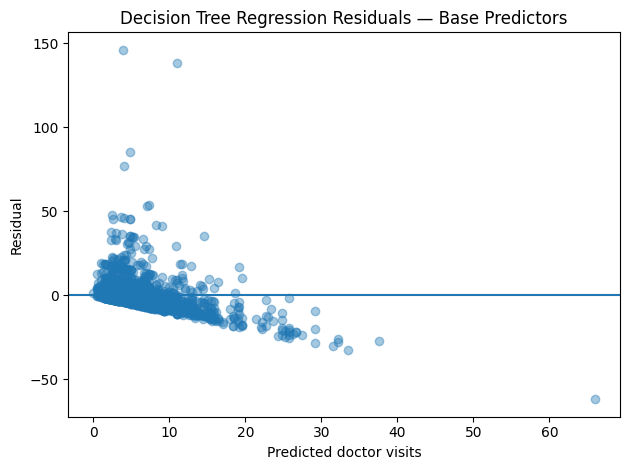

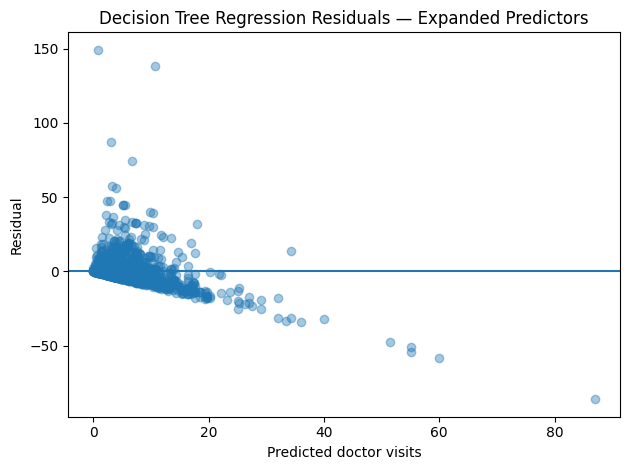

In [30]:
# Base
plt.scatter(pred_final_base, y_test_reg - pred_final_base, alpha=0.4)
plt.axhline(0)
plt.xlabel('Predicted doctor visits')
plt.ylabel('Residual')
plt.title('Decision Tree Regression Residuals — Base Predictors')
plt.tight_layout()
plt.show()

# Expanded
plt.scatter(pred_final_expanded, y_test_reg - pred_final_expanded, alpha=0.4)
plt.axhline(0)
plt.xlabel('Predicted doctor visits')
plt.ylabel('Residual')
plt.title('Decision Tree Regression Residuals — Expanded Predictors')
plt.tight_layout()
plt.show()


In [31]:
comparison = pd.DataFrame({
    'Baseline Base': baseline_test_base,
    'Baseline Expanded': baseline_test_expanded,
    'Tuned Base': final_metrics_base,
    'Tuned Expanded': final_metrics_expanded
}).T

print(comparison.round(3))

                     MAE    RMSE     R²
Baseline Base      6.209  14.254 -2.030
Baseline Expanded  6.121  13.734 -1.813
Tuned Base         4.844   8.993 -0.206
Tuned Expanded     4.647   9.071 -0.227
